# SEA single-drift experiment
Debug notebook for the DNN + Autoencoder concept drift detection pipeline.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

from tscls.datasets.sea import SEA
from tscls.pipeline.detector import Detector
from tscls.pipeline.monitor import StreamMonitor
from tscls.pipeline.pipeline_config import (
    PipelineConfig,
    DNNModelConfig,
    AutoencoderConfig,
    OptimizationConfig,
    TrainingConfig,
)
from tscls.simulation.stream_simulation import StreamSimulator

plt.rcParams.update({
    "font.size":        13,
    "axes.titlesize":   14,
    "axes.labelsize":   13,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  11,
})

## Parameters

In [2]:
n1       = 5_000   # reference samples
n2       = 5_000   # stream samples
drift_pos = 2_500  # stream index at which concept changes
f_old    = 3       # SEA concept before drift  (theta=9.5)
f_new    = 2       # SEA concept after drift   (theta=7.0)
seed     = 0

## Data generation

In [3]:
def prepare_sea_data(
    n1: int = 5_000,
    n2: int = 5_000,
    drift_pos: int = 2_500,
    f1: int = 3,
    f2: int = 2,
    seed: int = 0,
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    XY1 = SEA(f1, balanced=True).generate(n1, seed=seed)

    x_pre,  y_pre  = SEA(f1).generate(drift_pos,        seed=seed + 1)
    x_post, y_post = SEA(f2).generate(n2 - drift_pos,   seed=seed + 2)
    XY2 = (
        np.vstack([x_pre, x_post]),
        np.concatenate([y_pre, y_post]),
    )
    return XY1, XY2


(X1, y1), (X2, y2) = prepare_sea_data(
    n1=n1, n2=n2, drift_pos=drift_pos, f1=f_old, f2=f_new, seed=seed
)

print(f"Reference : {X1.shape}  classes={np.unique(y1, return_counts=True)[1]}")
print(f"Stream    : {X2.shape}  classes={np.unique(y2, return_counts=True)[1]}")

Reference : (5000, 3)  classes=[2500 2500]
Stream    : (5000, 3)  classes=[2500 2500]


## Training and stream time series

The SEA decision boundary depends on $x_0 + x_1 \leq \theta$.
Plotting that sum makes the concept shift visible.

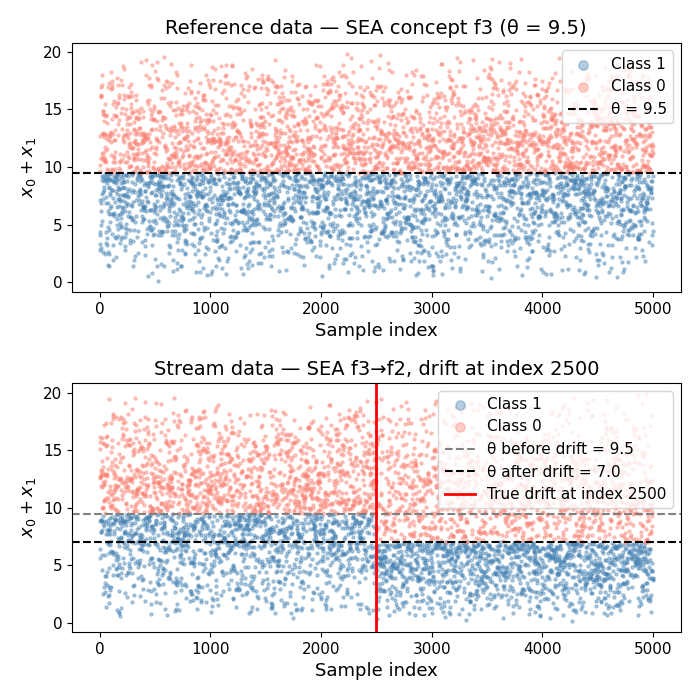

In [4]:
theta_old = SEA(f_old).threshold
theta_new = SEA(f_new).threshold

fig, axes = plt.subplots(2, 1, figsize=(7, 7))

# --- Reference data (training) ---
ax = axes[0]
idx_ref = np.arange(len(y1))
feat_sum_ref = X1[:, 0] + X1[:, 1]
ax.scatter(
    idx_ref[y1 == 1], feat_sum_ref[y1 == 1],
    s=5, alpha=0.4, c="steelblue", label="Class 1",
)
ax.scatter(
    idx_ref[y1 == 0], feat_sum_ref[y1 == 0],
    s=5, alpha=0.4, c="salmon", label="Class 0",
)
ax.axhline(
    theta_old, color="black", linestyle="--", linewidth=1.5,
    label=f"θ = {theta_old}",
)
ax.set_title(f"Reference data — SEA concept f{f_old} (θ = {theta_old})")
ax.set_xlabel("Sample index")
ax.set_ylabel("$x_0 + x_1$")
ax.legend(markerscale=3, loc="upper right")

# --- Stream data (testing) ---
ax = axes[1]
idx_stream = np.arange(len(y2))
feat_sum_stream = X2[:, 0] + X2[:, 1]
ax.scatter(
    idx_stream[y2 == 1], feat_sum_stream[y2 == 1],
    s=5, alpha=0.4, c="steelblue", label="Class 1",
)
ax.scatter(
    idx_stream[y2 == 0], feat_sum_stream[y2 == 0],
    s=5, alpha=0.4, c="salmon", label="Class 0",
)
ax.axhline(
    theta_old, color="gray", linestyle="--", linewidth=1.5,
    label=f"θ before drift = {theta_old}",
)
ax.axhline(
    theta_new, color="black", linestyle="--", linewidth=1.5,
    label=f"θ after drift = {theta_new}",
)
ax.axvline(
    drift_pos, color="red", linestyle="-", linewidth=2.0,
    label=f"True drift at index {drift_pos}",
)
ax.set_title(f"Stream data — SEA f{f_old}→f{f_new}, drift at index {drift_pos}")
ax.set_xlabel("Sample index")
ax.set_ylabel("$x_0 + x_1$")
ax.legend(markerscale=3, loc="upper right")

plt.tight_layout()
plt.show()

## Pipeline configuration

In [5]:
def build_config(num_features: int) -> PipelineConfig:
    return PipelineConfig(
        model=DNNModelConfig(
            layer_sizes=[num_features, 256, 128, 64, 1],
        ),
        autoencoder=AutoencoderConfig(
            encoder_sizes=[64, 32, 8],
            activation="relu",
            threshold_k=3.0,
        ),
        optimization=OptimizationConfig(
            base_loss_name="bce_with_logits",
            ae_loss_name="mse",
            stream_loss_name="bce_with_logits",
            base_optimizer_name="sgd",
            ae_optimizer_name="adam",
            stream_optimizer_name="sgd",
            base_learning_rate=1e-2,
            ae_learning_rate=1e-4,
            stream_learning_rate=1e-4,
            gamma1=0.9,
            s1=20,
            gamma2=1.0,
            s2=10,
        ),
        training=TrainingConfig(
            base_epochs=1000,
            ae_epochs=4000,
            batch_size=256,
        ),
    )


config = build_config(num_features=SEA(f_old).num_features)

## Offline training (fit)

In [6]:
detector = Detector(config=config)
print(f"Training on: {detector.device}")
detector.fit(X1, y1)
print("Offline training complete.")

Training on: cuda
Offline training complete.


## Training loss curves

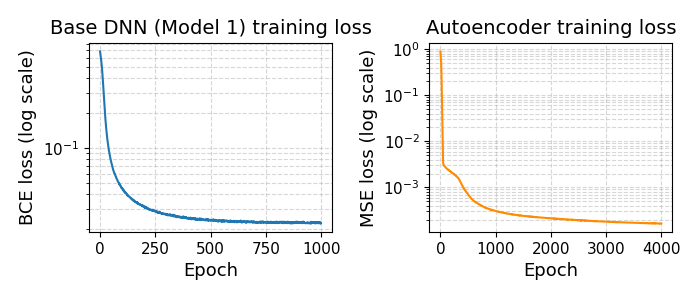

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].plot(detector.base_train_losses)
axes[0].set_yscale("log")
axes[0].set_title("Base DNN (Model 1) training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss (log scale)")
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)

axes[1].plot(detector.ae_train_losses, color="darkorange")
axes[1].set_yscale("log")
axes[1].set_title("Autoencoder training loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE loss (log scale)")
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Online stream monitoring

In [8]:
monitor = StreamMonitor(detector=detector)
stream  = StreamSimulator(data=X2, labels=y2)
result  = monitor.run(stream)

print(f"Detected drift points (first 20): {result.drift_points[:20]}")
print(f"Total detected: {len(result.drift_points)}")
if result.drift_points:
    delay = result.drift_points[0] - drift_pos
    print(f"First detected at index {result.drift_points[0]}  (delay = {delay})")
else:
    print("No drift detected.")

Detected drift points (first 20): [28, 148, 206, 214, 265, 311, 325, 427, 437, 452, 564, 607, 648, 748, 789, 863, 923, 948, 963, 984]
Total detected: 144
First detected at index 28  (delay = -2472)


## Detection results

Reconstruction error over the stream, with the calibrated threshold band,
the true drift position, and the detected drift points.

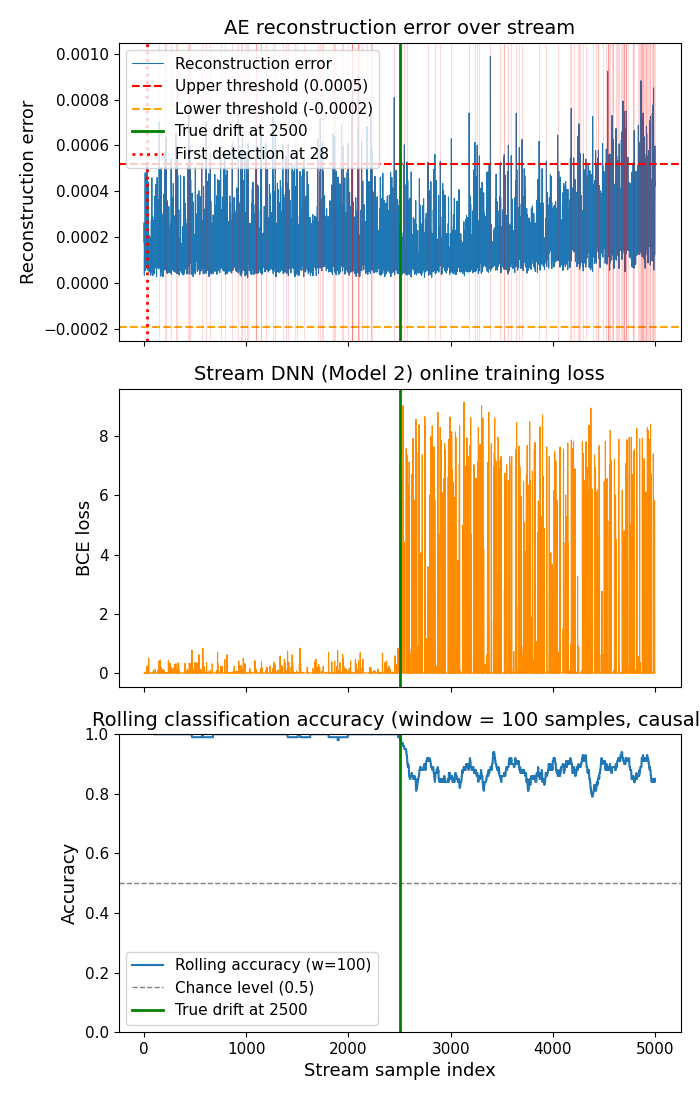

In [14]:
errors = np.array(result.reconstruction_errors)
losses = np.array(result.training_losses)
preds  = np.array(result.predictions)

stats      = detector.threshold_rule.stats   # ThresholdStat: .mean .std .lower .upper
stream_idx = np.arange(len(errors))

# Rolling accuracy — causal: each point is the mean of the past `window` samples
window      = 100
is_correct  = (np.round(preds) == y2).astype(float)
rolling_acc = np.convolve(is_correct, np.ones(window) / window, mode="valid")
rolling_idx = np.arange(window - 1, window - 1 + len(rolling_acc))

fig, axes = plt.subplots(3, 1, figsize=(7, 11), sharex=True)

# --- Reconstruction error ---
ax = axes[0]
ax.plot(stream_idx, errors, linewidth=0.8, label="Reconstruction error")
ax.axhline(
    stats.upper, color="red", linestyle="--", linewidth=1.5,
    label=f"Upper threshold ({stats.upper:.4f})",
)
ax.axhline(
    stats.lower, color="orange", linestyle="--", linewidth=1.5,
    label=f"Lower threshold ({stats.lower:.4f})",
)
ax.axvline(
    drift_pos, color="green", linestyle="-", linewidth=2.0,
    label=f"True drift at {drift_pos}",
)
for dp in result.drift_points:
    ax.axvline(dp, color="red", alpha=0.15, linewidth=0.8)
if result.drift_points:
    ax.axvline(
        result.drift_points[0], color="red", linewidth=2.0,
        linestyle=":", label=f"First detection at {result.drift_points[0]}",
    )
ax.set_title("AE reconstruction error over stream")
ax.set_ylabel("Reconstruction error")
ax.legend(loc="upper left")

# --- Online training loss ---
ax = axes[1]
ax.plot(stream_idx, losses, linewidth=0.8, color="darkorange")
ax.axvline(drift_pos, color="green", linestyle="-", linewidth=2.0)
ax.set_title("Stream DNN (Model 2) online training loss")
ax.set_ylabel("BCE loss")

# --- Rolling accuracy ---
ax = axes[2]
ax.plot(rolling_idx, rolling_acc, linewidth=1.5, label=f"Rolling accuracy (w={window})")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, label="Chance level (0.5)")
ax.axvline(
    drift_pos, color="green", linestyle="-", linewidth=2.0,
    label=f"True drift at {drift_pos}",
)
ax.set_ylim(0, 1)
ax.set_title(f"Rolling classification accuracy (window = {window} samples, causal)")
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

## Debug: reference vs stream reconstruction errors

Re-compute reconstruction errors on the reference data and compare with stream errors.
This shows whether the threshold is calibrated in a sensible range.

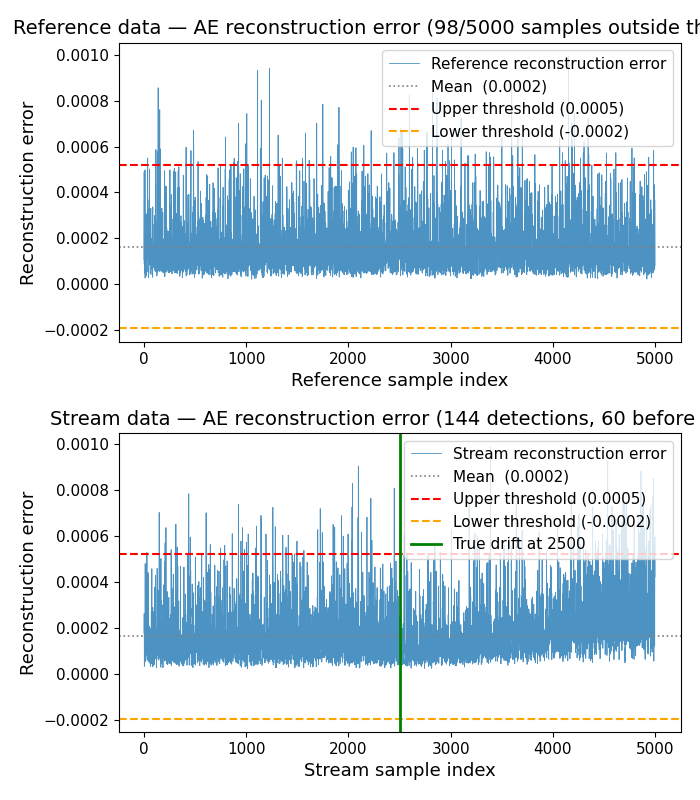

Threshold stats  — mean: 0.000164  std: 0.000119
Bounds           — lower: -0.000194  upper: 0.000521
Reference FP     — 98/5000 (2.0%)


In [10]:
import torch

detector.base_model.eval()
detector.autoencoder.eval()

x1_scaled = detector.scaler.transform(X1.astype(np.float32))
x1_t      = torch.tensor(x1_scaled, dtype=torch.float32).to(detector.device)

with torch.no_grad():
    _, ref_latents  = detector.base_model.forward_with_latent(x1_t)
    _, ref_errors_t = detector.autoencoder.reconstruction_error(ref_latents)

ref_errors = ref_errors_t.cpu().numpy()
ref_idx    = np.arange(len(ref_errors))

fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# --- Reference reconstruction errors ---
ax = axes[0]
ax.plot(ref_idx, ref_errors, linewidth=0.6, alpha=0.8, label="Reference reconstruction error")
ax.axhline(
    stats.mean,  color="gray",   linestyle=":",  linewidth=1.2,
    label=f"Mean  ({stats.mean:.4f})",
)
ax.axhline(
    stats.upper, color="red",    linestyle="--", linewidth=1.5,
    label=f"Upper threshold ({stats.upper:.4f})",
)
ax.axhline(
    stats.lower, color="orange", linestyle="--", linewidth=1.5,
    label=f"Lower threshold ({stats.lower:.4f})",
)
n_fp = int(np.sum((ref_errors > stats.upper) | (ref_errors < stats.lower)))
ax.set_title(
    f"Reference data — AE reconstruction error "
    f"({n_fp}/{len(ref_errors)} samples outside threshold)"
)
ax.set_xlabel("Reference sample index")
ax.set_ylabel("Reconstruction error")
ax.legend(loc="upper right")

# --- Stream reconstruction errors ---
ax = axes[1]
ax.plot(stream_idx, errors, linewidth=0.6, alpha=0.8, label="Stream reconstruction error")
ax.axhline(
    stats.mean,  color="gray",   linestyle=":",  linewidth=1.2,
    label=f"Mean  ({stats.mean:.4f})",
)
ax.axhline(
    stats.upper, color="red",    linestyle="--", linewidth=1.5,
    label=f"Upper threshold ({stats.upper:.4f})",
)
ax.axhline(
    stats.lower, color="orange", linestyle="--", linewidth=1.5,
    label=f"Lower threshold ({stats.lower:.4f})",
)
ax.axvline(
    drift_pos, color="green", linestyle="-", linewidth=2.0,
    label=f"True drift at {drift_pos}",
)
n_before = sum(d < drift_pos for d in result.drift_points)
ax.set_title(
    f"Stream data — AE reconstruction error "
    f"({len(result.drift_points)} detections, {n_before} before drift)"
)
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Reconstruction error")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"Threshold stats  — mean: {stats.mean:.6f}  std: {stats.std:.6f}")
print(f"Bounds           — lower: {stats.lower:.6f}  upper: {stats.upper:.6f}")
print(f"Reference FP     — {n_fp}/{len(ref_errors)} ({100*n_fp/len(ref_errors):.1f}%)")

## Reconstruction error distributions

Overlaid histograms (density-normalized) of AE reconstruction errors **before** the true drift (stream indices `< drift_pos`) and **after** (`≥ drift_pos`), using the same `errors` array as above.

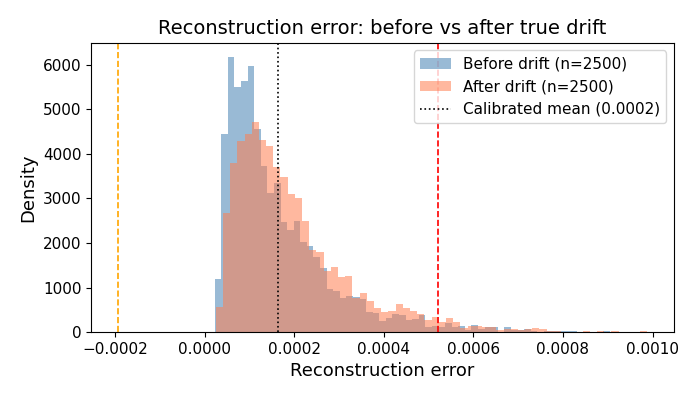

In [11]:
pre_err = errors[:drift_pos]
post_err = errors[drift_pos:]

fig, ax = plt.subplots(figsize=(7, 4))
bins = 60
ax.hist(
    pre_err,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"Before drift (n={len(pre_err)})",
    color="steelblue",
)
ax.hist(
    post_err,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"After drift (n={len(post_err)})",
    color="coral",
)
ax.axvline(
    stats.mean, color="black", linestyle=":", linewidth=1.2,
    label=f"Calibrated mean ({stats.mean:.4f})",
)
ax.axvline(stats.lower, color="orange", linestyle="--", linewidth=1.2)
ax.axvline(stats.upper, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Reconstruction error")
ax.set_ylabel("Density")
ax.set_title("Reconstruction error: before vs after true drift")
ax.legend(loc="best")
plt.tight_layout()
plt.show()